**1 - MOUNT DRIVE & INSTALL**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install PySastrawi transformers torch -q

import pandas as pd
import numpy as np
import re
import os
import unicodedata
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from transformers import AutoTokenizer
from sklearn.feature_extraction.text import TfidfVectorizer

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 2.6 MB/s eta 0:00:00


**2 - LOAD DATA**

In [ ]:
df1 = pd.read_csv("/content/drive/MyDrive/SKRIPSI/CODE/CRAWLING DATA/DATA AKHIR/Fase1_Pra_Implementasi_MBG.csv")
df2 = pd.read_csv("/content/drive/MyDrive/SKRIPSI/CODE/CRAWLING DATA/DATA AKHIR/Fase2_Implementasi_MBG.csv")

print(f"✅ Fase 1 - Pra-Implementasi : {len(df1)} tweet")
print(f"✅ Fase 2 - Implementasi     : {len(df2)} tweet")
print(f"✅ Total data awal           : {len(df1) + len(df2)} tweet")

✅ Fase 1 - Pra-Implementasi : 1633 tweet
✅ Fase 2 - Implementasi     : 3477 tweet
✅ Total data awal           : 5110 tweet


**3 - GABUNG DATA & LOAD KAMUS NORMALISASI**

In [ ]:
df = pd.concat([df1, df2], ignore_index=True)

kamus_df = pd.read_csv("/content/drive/MyDrive/SKRIPSI/CODE/colloquial-indonesian-lexicon.csv")
kamus_normalisasi = dict(zip(kamus_df['slang'], kamus_df['formal']))

print(f"✅ Data digabung            : {len(df)} tweet")
print(f"✅ Kamus normalisasi loaded : {len(kamus_normalisasi)} kata")

✅ Data digabung            : 5110 tweet
✅ Kamus normalisasi loaded : 4331 kata


**4 - PRE-PROCESSING AWAL**

In [ ]:
# ============================================================
# (Normalisasi, Lowercase, Deduplication)
# ============================================================
def normalize(text):
    text = re.sub(r'http\S+|www\S+', '', text)      # Hapus URL
    text = re.sub(r'@\w+', '', text)                 # Hapus mention (@username)
    text = re.sub(r'#', '', text)                    # Hapus simbol hashtag (#)
    text = ''.join(c for c in text if not unicodedata.category(c).startswith('So'))  # Hapus emoji
    text = re.sub(r'[^a-zA-Z\s]', '', text)          # Hapus karakter non-alfabet & angka
    text = re.sub(r'(.)\1{2,}', r'\1', text)         # Kurangi karakter berulang (misal: "bagussss" → "bagus")
    words = text.split()
    words = [kamus_normalisasi.get(w, w) for w in words]  # Normalisasi kata tidak baku (slang → baku)
    return ' '.join(words).strip()

def preprocess_awal(text):
    text = normalize(text)                           # Terapkan normalisasi
    text = text.lower()                              # Lowercase (huruf kecil semua)
    return text

# Terapkan fungsi preprocessing ke kolom full_text
df['text_clean'] = df['full_text'].astype(str).apply(preprocess_awal)

# Deduplication berbasis ID (hapus tweet yang terambil lebih dari satu kali)
sebelum_dedup = len(df)
df = df.drop_duplicates(subset=['id_str'])
sesudah_dedup = len(df)
print(f"✅ Deduplication: {sebelum_dedup} → {sesudah_dedup} tweet")
print(f"   {sebelum_dedup - sesudah_dedup} duplikat dihapus")

# Hapus baris dengan teks kosong setelah preprocessing
df = df[df['text_clean'].str.strip() != '']
print(f"✅ Total data setelah pre-processing awal: {len(df)} tweet")

# Tampilkan perbandingan sebelum dan sesudah preprocessing
print("\n📊 Contoh Hasil Pre-processing:")
df[['full_text', 'text_clean']].head(10)

✅ Deduplication: 5110 → 2539 tweet
   2571 duplikat dihapus
✅ Total data setelah pre-processing awal: 2539 tweet

📊 Contoh Hasil Pre-processing:


,full_text,text_clean
0,"Gelar Makan Bergizi Gratis, HNSI Siap Berkolab...",gelar makan bergizi gratis hnsi siap berkolabo...
1,#SahabatBahari berikut keseruan dari pelaksana...,sahabatbahari berikut keseruan dari pelaksanaa...
2,"""Memang Rp 10 ribu, Rp 15 ribu, itu semua cuku...",memang rp ribu rp ribu itu semua cukup kalau m...
3,"Presiden ke-5 RI, Megawati Soekarnoputri menyi...",presiden ke ri megawati soekarnoputri menyingg...
4,"Rayakan HUT ke -19, Bakamla Zona Barat Beri Ma...",rayakan hut ke bakamla zona barat beri makan b...
5,#SahabatBahari Program Makan Bergizi Gratis (M...,sahabatbahari program makan bergizi gratis mbg...
6,Lanud Adi Soemarmo Uji Coba Memasak Guna Mendu...,lanud adi soemarmo uji coba memasak guna mendu...
7,"Soal Program Makan Bergizi Gratis, Senator Ahm...",soal program makan bergizi gratis senator ahma...
8,DKP Maluku bagikan 1.121 paket makan bergizi g...,dkp maluku bagikan paket makan bergizi gratis ...
9,"Lewat Pembiayaan dan Pemberdayaan, BRI Suksesk...",lewat pembiayaan dan pemberdayaan bri sukseska...


**4.1 → Cari contoh untuk tabel laporan**

In [ ]:
# ============================================================
# CELL 4.1 - CONTOH HASIL CLEANING UNTUK TABEL LAPORAN
# ============================================================

import pandas as pd

# TAMBAHKAN INI: Supaya teks di kolom tidak terpotong saat ditampilkan
pd.set_option('display.max_colwidth', None)

# Contoh Hapus URL
url_example = df[df['full_text'].str.contains('http', na=False)][['full_text', 'text_clean']].head(5)

# Contoh Hapus Mention
mention_example = df[df['full_text'].str.contains('@', na=False)][['full_text', 'text_clean']].head(5)

# Contoh Hapus Hashtag
hashtag_example = df[df['full_text'].str.contains('#', na=False)][['full_text', 'text_clean']].head(5)

# Contoh Hapus Emoji
emoji_example = df[df['full_text'].str.contains('[^\x00-\x7F]', na=False, regex=True)][['full_text', 'text_clean']].head(5)

# Contoh Lowercase
lower_example = df[df['full_text'].str.contains('[A-Z]{2,}', na=False, regex=True)][['full_text', 'text_clean']].head(5)

# Contoh Hapus Angka & Tanda Baca
angka_example = df[df['full_text'].str.contains(r'\d+', na=False, regex=True)][['full_text', 'text_clean']].head(5)

# Label proses
url_example.insert(0, 'Proses', 'Hapus URL')
mention_example.insert(0, 'Proses', 'Hapus Mention')
hashtag_example.insert(0, 'Proses', 'Hapus Hashtag')
emoji_example.insert(0, 'Proses', 'Hapus Emoji')
lower_example.insert(0, 'Proses', 'Lowercase')
angka_example.insert(0, 'Proses', 'Hapus Angka & Tanda Baca')

# Tampilkan per proses biar mudah dipilih
print("=== Hapus URL ===")
display(url_example)

print("=== Hapus Mention ===")
display(mention_example)

print("=== Hapus Hashtag ===")
display(hashtag_example)

print("=== Hapus Emoji ===")
display(emoji_example)

print("=== Lowercase ===")
display(lower_example)

print("=== Hapus Angka & Tanda Baca ===")
display(angka_example)

=== Hapus URL ===


,Proses,full_text,text_clean
0,Hapus URL,"Gelar Makan Bergizi Gratis, HNSI Siap Berkolaborasi dengan Pemerintah\n\nhttps://t.co/DoW1PZ0cZ6",gelar makan bergizi gratis hnsi siap berkolaborasi dengan pemerintah
1,Hapus URL,#SahabatBahari berikut keseruan dari pelaksanaan Makan Bergizi Gratis yang dilaksanakan BRPBAP3 Maros. Para siswa juga menyampaikan rasa terima kasih atas adanya kegiatan Makan Bergizi Gratis ini. \nhttps://t.co/HshYoYnDzx,sahabatbahari berikut keseruan dari pelaksanaan makan bergizi gratis yang dilaksanakan brpbap maros para siswa juga menyampaikan rasa terima kasih atas adanya kegiatan makan bergizi gratis ini
2,Hapus URL,"""Memang Rp 10 ribu, Rp 15 ribu, itu semua cukup kalau misalnya kita berikan sesuai porsi,"" ujar Kepala Bapanas Arief yang yakin harga satuan porsi program makan bergizi gratis cukup. https://t.co/lKfuQXItaV",memang rp ribu rp ribu itu semua cukup kalau misalnya kita berikan sesuai porsi ujar kepala bapanas arief yang yakin harga satuan porsi program makan bergizi gratis cukup
3,Hapus URL,"Presiden ke-5 RI, Megawati Soekarnoputri menyinggung program Makan Bergizi Gratis (MBG) yang digagas Presiden Prabowo Subianto. Dia setuju dengan program itu, namun meminta Prabowo untuk menghitung lagi harga Rp 10 ribu per menu untuk program itu.\n\n""Kuhitung Rp 10 ribu toh apa https://t.co/WlEGKpjErW",presiden ke ri megawati soekarnoputri menyinggung program makan bergizi gratis mbg yang digagas presiden prabowo subianto dia setuju dengan program itu namun meminta prabowo untuk menghitung lagi harga rp ribu per menu untuk program itu kuhitung rp ribu toh apa
4,Hapus URL,"Rayakan HUT ke -19, Bakamla Zona Barat Beri Makan Bergizi Gratis kepada Murid SD di Sagulung\n\nhttps://t.co/CkaGKXIzjZ",rayakan hut ke bakamla zona barat beri makan bergizi gratis kepada murid sd di sagulung


=== Hapus Mention ===


,Proses,full_text,text_clean
9,Hapus Mention,"Lewat Pembiayaan dan Pemberdayaan, BRI Sukseskan Program Makan Bergizi Gratis https://t.co/Ar7mWG887d lewat @Keuangan News",lewat pembiayaan dan pemberdayaan bri sukseskan program makan bergizi gratis lewat news
10,Hapus Mention,"Ketua Umum PDIP, Megawati Soekarnoputri, menegaskan secara prinsip, dirinya mendukung dan setuju dengan program unggulan Presiden @prabowo, Makan Bergizi Gratis (MBG).\n\nKendati setuju dengan program ini, Megawati menilai perencanaan program makan bergizi gratis itu perlu https://t.co/HO08uWYtl4",ketua umum pdip megawati soekarnoputri menegaskan secara prinsip dirinya mendukung dan setuju dengan program unggulan presiden makan bergizi gratis mbg kendati setuju dengan program ini megawati menilai perencanaan program makan bergizi gratis itu perlu
18,Hapus Mention,KAWAL KETAT JENDERAL..! Dr. Widjaja Lukito Sebut Rp 10.000/Porsi Relatif Cukup Untuk Makan Bergizi Gratis: Asal Jangan Dikorup Lagi! https://t.co/r2WCRsxYb1 lewat @BERGELORA.COM https://t.co/XdnquPvBu5,kawal ketat jenderal dr widjaja lukito sebut rp porsi relatif cukup untuk makan bergizi gratis asal jangan dikorup lagi lewat com
19,Hapus Mention,Gus Menko ⁦@cakimiNOW⁩ merespons usulan Ketum PDIP Megawati untuk Presiden Prabowo Subianto mengkaji kembali anggaran makan bergizi gratis senilai Rp 10.000/porsi.\n\n https://t.co/TVgT0WXBL3,gus menko merespons usulan ketum pdip megawati untuk presiden prabowo subianto mengkaji kembali anggaran makan bergizi gratis senilai rp porsi
22,Hapus Mention,"Wapres Gibran Rakabuming hadir di Konferensi Besar Fatayat NU 2024 di Menteng Jakpus, Jumat (13/12/24). Ia meminta Fatayat NU ikut mengawal Program Kabinet Merah Putih, seperti makan bergizi gratis &amp; ikut mendeteksi dini kekerasan pd perempuan &amp; anak\n\n#LiputanSonora by @Miroliaa https://t.co/4hYnWM2WyQ",wapres gibran rakabuming hadir di konferensi besar fatayat nu di menteng jakpus jumat ia meminta fatayat nu ikut mengawal program kabinet merah putih seperti makan bergizi gratis amp ikut mendeteksi dini kekerasan pada perempuan amp anak liputansonora by


=== Hapus Hashtag ===


...

,Proses,full_text,text_clean
19,Hapus Emoji,Gus Menko ⁦@cakimiNOW⁩ merespons usulan Ketum PDIP Megawati untuk Presiden Prabowo Subianto mengkaji kembali anggaran makan bergizi gratis senilai Rp 10.000/porsi.\n\n https://t.co/TVgT0WXBL3,gus menko merespons usulan ketum pdip megawati untuk presiden prabowo subianto mengkaji kembali anggaran makan bergizi gratis senilai rp porsi
52,Hapus Emoji,"Ketua Umum Dewan Pimpinan Nasional HKTI, Fadli Zon mendorong HKTI Jabar menjadi lumbung padi untuk mendukung program makan bergizi gratis, Sabtu (14/12). 🎥Buh\n#BeritaElshinta https://t.co/onBfhGMJfG",ketua umum dewan pimpinan nasional hkti fadli zon mendorong hkti jabar menjadi lumbung padi untuk mendukung program makan bergizi gratis sabtu buh beritaelshinta
66,Hapus Emoji,"Pemerintah siap melaksanakan Program Makan Bergizi Gratis (MBG) mulai 2 Januari 2025! 🍽️⁣\n⁣\nDalam proses uji coba selama beberapa bulan terakhir, pemerintah telah menemukan format ideal dalam proses pelaksanaan program. Pemerintah juga telah mulai penyediaan bahan baku, https://t.co/3BwrjG1dqA",pemerintah siap melaksanakan program makan bergizi gratis mbg mulai januari dalam proses uji coba selama beberapa bulan terakhir pemerintah telah menemukan format ideal dalam proses pelaksanaan program pemerintah juga telah mulai penyediaan bahan baku
77,Hapus Emoji,"#MinaMania, mari kita lihat lagi keseruan Makan Bergizi Gratis di Tanjung Pasir, Tangerang yang melibatkan 1000 orang mulai dari anak TK hingga ibu menyusui.\n\nMakan ikan setiap hari, wujudkan Generasi Emas 2045 bersama protein ikan. 🐟✨\n\nhttps://t.co/PdoukthbBP\n\n#HariNusantara",minamania mari kita lihat lagi keseruan makan bergizi gratis di tanjung pasir tangerang yang melibatkan orang mulai dari anak tk hingga ibu menyusui makan ikan setiap hari wujudkan generasi emas bersama protein ikan harinusantara
92,Hapus Emoji,Wakil Presiden Gibran Rakabuming Raka mengklaim ibu-ibu menjadi kelompok yang paling mendukung pelaksanaan program makan bergizi gratis.\n\nGibran mengatakan para ibu-ibu sangat antusias ketika menjalankan simulasi program makan bergizi gratis di sejumlah sekolah.\n\nHal tersebut https://t.co/skz7VDzMg9,wakil presiden gibran rakabuming raka mengklaim ibuibu menjadi kelompok yang paling mendukung pelaksanaan program makan bergizi gratis gibran mengatakan para ibuibu sangat antusias ketika menjalankan simulasi program makan bergizi gratis di sejumlah sekolah hal tersebut


=== Lowercase ===


,Proses,full_text,text_clean
0,Lowercase,"Gelar Makan Bergizi Gratis, HNSI Siap Berkolaborasi dengan Pemerintah\n\nhttps://t.co/DoW1PZ0cZ6",gelar makan bergizi gratis hnsi siap berkolaborasi dengan pemerintah
1,Lowercase,#SahabatBahari berikut keseruan dari pelaksanaan Makan Bergizi Gratis yang dilaksanakan BRPBAP3 Maros. Para siswa juga menyampaikan rasa terima kasih atas adanya kegiatan Makan Bergizi Gratis ini. \nhttps://t.co/HshYoYnDzx,sahabatbahari berikut keseruan dari pelaksanaan makan bergizi gratis yang dilaksanakan brpbap maros para siswa juga menyampaikan rasa terima kasih atas adanya kegiatan makan bergizi gratis ini
2,Lowercase,"""Memang Rp 10 ribu, Rp 15 ribu, itu semua cukup kalau misalnya kita berikan sesuai porsi,"" ujar Kepala Bapanas Arief yang yakin harga satuan porsi program makan bergizi gratis cukup. https://t.co/lKfuQXItaV",memang rp ribu rp ribu itu semua cukup kalau misalnya kita berikan sesuai porsi ujar kepala bapanas arief yang yakin harga satuan porsi program makan bergizi gratis cukup
3,Lowercase,"Presiden ke-5 RI, Megawati Soekarnoputri menyinggung program Makan Bergizi Gratis (MBG) yang digagas Presiden Prabowo Subianto. Dia setuju dengan program itu, namun meminta Prabowo untuk menghitung lagi harga Rp 10 ribu per menu untuk program itu.\n\n""Kuhitung Rp 10 ribu toh apa https://t.co/WlEGKpjErW",presiden ke ri megawati soekarnoputri menyinggung program makan bergizi gratis mbg yang digagas presiden prabowo subianto dia setuju dengan program itu namun meminta prabowo untuk menghitung lagi harga rp ribu per menu untuk program itu kuhitung rp ribu toh apa
4,Lowercase,"Rayakan HUT ke -19, Bakamla Zona Barat Beri Makan Bergizi Gratis kepada Murid SD di Sagulung\n\nhttps://t.co/CkaGKXIzjZ",rayakan hut ke bakamla zona barat beri makan bergizi gratis kepada murid sd di sagulung


=== Hapus Angka & Tanda Baca ===


,Proses,full_text,text_clean
0,Hapus Angka & Tanda Baca,"Gelar Makan Bergizi Gratis, HNSI Siap Berkolaborasi dengan Pemerintah\n\nhttps://t.co/DoW1PZ0cZ6",gelar makan bergizi gratis hnsi siap berkolaborasi dengan pemerintah
1,Hapus Angka & Tanda Baca,#SahabatBahari berikut keseruan dari pelaksanaan Makan Bergizi Gratis yang dilaksanakan BRPBAP3 Maros. Para siswa juga menyampaikan rasa terima kasih atas adanya kegiatan Makan Bergizi Gratis ini. \nhttps://t.co/HshYoYnDzx,sahabatbahari berikut keseruan dari pelaksanaan makan bergizi gratis yang dilaksanakan brpbap maros para siswa juga menyampaikan rasa terima kasih atas adanya kegiatan makan bergizi gratis ini
2,Hapus Angka & Tanda Baca,"""Memang Rp 10 ribu, Rp 15 ribu, itu semua cukup kalau misalnya kita berikan sesuai porsi,"" ujar Kepala Bapanas Arief yang yakin harga satuan porsi program makan bergizi gratis cukup. https://t.co/lKfuQXItaV",memang rp ribu rp ribu itu semua cukup kalau misalnya kita berikan sesuai porsi ujar kepala bapanas arief yang yakin harga satuan porsi program makan bergizi gratis cukup
3,Hapus Angka & Tanda Baca,"Presiden ke-5 RI, Megawati Soekarnoputri menyinggung program Makan Bergizi Gratis (MBG) yang digagas Presiden Prabowo Subianto. Dia setuju dengan program itu, namun meminta Prabowo untuk menghitung lagi harga Rp 10 ribu per menu untuk program itu.\n\n""Kuhitung Rp 10 ribu toh apa https://t.co/WlEGKpjErW",presiden ke ri megawati soekarnoputri menyinggung program makan bergizi gratis mbg yang digagas presiden prabowo subianto dia setuju dengan program itu namun meminta prabowo untuk menghitung lagi harga rp ribu per menu untuk program itu kuhitung rp ribu toh apa
4,Hapus Angka & Tanda Baca,"Rayakan HUT ke -19, Bakamla Zona Barat Beri Makan Bergizi Gratis kepada Murid SD di Sagulung\n\nhttps://t.co/CkaGKXIzjZ",rayakan hut ke bakamla zona barat beri makan bergizi gratis kepada murid sd di sagulung


**5 - PRE-PROCESSING LANJUTAN SVM**

In [ ]:
# ============================================================
# (Stopword Removal + TF-IDF)
# ============================================================
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

def remove_stopwords(text):
    return stopword_remover.remove(text)

df['text_svm'] = df['text_clean'].apply(remove_stopwords)
print(f"✅ Stopword removal selesai")

tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['text_svm'])
print(f"✅ TF-IDF selesai")
print(f"   Jumlah fitur : {X_tfidf.shape[1]}")
print(f"   Jumlah data  : {X_tfidf.shape[0]}")

✅ Stopword removal selesai
✅ TF-IDF selesai
   Jumlah fitur : 5000
   Jumlah data  : 2539


**CONTOH STOPWORD REMOVAL**

In [ ]:
# ============================================================
# CONTOH HASIL STOPWORD REMOVAL
# ============================================================

tabel_stopword = df[['text_clean', 'text_svm']].head(3)

tabel_stopword

,text_clean,text_svm
0,gelar makan bergizi gratis hnsi siap berkolaborasi dengan pemerintah,gelar makan bergizi gratis hnsi berkolaborasi pemerintah
1,sahabatbahari berikut keseruan dari pelaksanaan makan bergizi gratis yang dilaksanakan brpbap maros para siswa juga menyampaikan rasa terima kasih atas adanya kegiatan makan bergizi gratis ini,sahabatbahari keseruan pelaksanaan makan bergizi gratis dilaksanakan brpbap maros siswa terima kasih kegiatan makan bergizi gratis
2,memang rp ribu rp ribu itu semua cukup kalau misalnya kita berikan sesuai porsi ujar kepala bapanas arief yang yakin harga satuan porsi program makan bergizi gratis cukup,rp ribu rp ribu sesuai porsi kepala bapanas arief harga satuan porsi program makan bergizi gratis


**CONTOH REPRESENTASI TF-IDF**

In [ ]:
# ============================================================
# CONTOH REPRESENTASI TF-IDF
# ============================================================

feature_names = tfidf.get_feature_names_out()

# Ambil representasi TF-IDF data pertama
dense = X_tfidf[0].todense().tolist()[0]

hasil_tfidf = []

for idx, value in enumerate(dense):
    if value > 0:
        hasil_tfidf.append((feature_names[idx], value))

# Buat dataframe
tfidf_df = pd.DataFrame(hasil_tfidf, columns=['Fitur', 'Bobot TF-IDF'])

# Tampilkan 10 fitur pertama
tfidf_df.head(10)

,Fitur,Bobot TF-IDF
0,bergizi,0.107835
1,berkolaborasi,0.567247
2,gelar,0.483639
3,gratis,0.108520
4,hnsi,0.589141
5,makan,0.107472
6,pemerintah,0.249562


**6 - PRE-PROCESSING LANJUTAN IndoBERT**

In [ ]:
# ============================================================
# (Tokenisasi)
# ============================================================
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

def tokenize_indobert(text):
    return tokenizer(
        text,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

contoh = tokenize_indobert(df['text_clean'].iloc[0])
print(f"✅ Tokenisasi IndoBERT siap")
print(f"   Input IDs shape  : {contoh['input_ids'].shape}")
print(f"   Attention Mask   : {contoh['attention_mask'].shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ Tokenisasi IndoBERT siap
   Input IDs shape  : torch.Size([1, 128])
   Attention Mask   : torch.Size([1, 128])


In [ ]:
# ============================================================
# TABEL CONTOH TOKENISASI INDOBERT
# ============================================================

import pandas as pd

hasil_tokenisasi = []

for i in range(3):
    text = df['text_clean'].iloc[i]

    # Tokenisasi subword
    tokens = tokenizer.tokenize(text)

    # Konversi token ke ID
    token_ids = tokenizer.convert_tokens_to_ids(tokens)

    hasil_tokenisasi.append({
        "Teks": text,
        "Token (Subword)": str(tokens),
        "Token IDs": str(token_ids)
    })

# Buat DataFrame
tabel_tokenisasi = pd.DataFrame(hasil_tokenisasi)

# Tampilkan tabel
tabel_tokenisasi

,Teks,Token (Subword),Token IDs
0,gelar makan bergizi gratis hnsi siap berkolaborasi dengan pemerintah,"['gelar', 'makan', 'bergizi', 'gratis', 'h', '##ns', '##i', 'siap', 'berkolaborasi', 'dengan', 'pemerintah']","[4263, 521, 15738, 1243, 40, 1080, 30356, 1480, 21220, 79, 877]"
1,sahabatbahari berikut keseruan dari pelaksanaan makan bergizi gratis yang dilaksanakan brpbap maros para siswa juga menyampaikan rasa terima kasih atas adanya kegiatan makan bergizi gratis ini,"['sahabat', '##bah', '##ari', 'berikut', 'keseruan', 'dari', 'pelaksanaan', 'makan', 'bergizi', 'gratis', 'yang', 'dilaksanakan', 'brp', '##ba', '##p', 'maros', 'para', 'siswa', 'juga', 'menyampaikan', 'rasa', 'terima', 'kasih', 'atas', 'adanya', 'kegiatan', 'makan', 'bergizi', 'gratis', 'ini']","[3229, 3791, 65, 713, 27546, 98, 2132, 521, 15738, 1243, 34, 2456, 14817, 96, 30367, 28226, 383, 980, 186, 3646, 1214, 1788, 1338, 441, 1051, 845, 521, 15738, 1243, 92]"
2,memang rp ribu rp ribu itu semua cukup kalau misalnya kita berikan sesuai porsi ujar kepala bapanas arief yang yakin harga satuan porsi program makan bergizi gratis cukup,"['memang', 'rp', 'ribu', 'rp', 'ribu', 'itu', 'semua', 'cukup', 'kalau', 'misalnya', 'kita', 'berikan', 'sesuai', 'porsi', 'ujar', 'kepala', 'bapa', '##nas', 'arief', 'yang', 'yakin', 'harga', 'satuan', 'porsi', 'program', 'makan', 'bergizi', 'gratis', 'cukup']","[731, 600, 2276, 600, 2276, 137, 366, 724, 599, 1330, 219, 2967, 786, 8823, 3612, 1179, 10538, 3234, 14654, 34, 2973, 405, 4006, 8823, 986, 521, 15738, 1243, 724]"


**7 - SIMPAN HASIL PRE-PROCESSING**

In [ ]:
# ============================================================
# CELL 7 - SIMPAN HASIL PRE-PROCESSING
# ============================================================
save_path = "/content/drive/MyDrive/SKRIPSI/CODE/HASIL_PREPROCESSING"
os.makedirs(save_path, exist_ok=True)

file_path = f"{save_path}/data_preprocessed.csv"

# Cek apakah file sudah ada
if os.path.exists(file_path):
    print(f"⚠️ File sudah ada, tidak perlu disimpan ulang!")
    print(f"📊 Total data: {len(df)} tweet")
else:
    df[['id_str', 'full_text', 'text_clean', 'text_svm']].to_csv(file_path, index=False)
    print(f"✅ Data hasil pre-processing tersimpan!")
    print(f"📊 Total data final: {len(df)} tweet")

⚠️ File sudah ada, tidak perlu disimpan ulang!
📊 Total data: 2539 tweet


In [ ]:
# ============================================================
# CELL 8 - EKSPOR FILE UNTUK PELABELAN ANOTATOR
# ============================================================
save_path_label = "/content/drive/MyDrive/SKRIPSI/CODE/HASIL_PREPROCESSING"

# Cek apakah file sudah ada
file_fase1 = f"{save_path_label}/data_anotasi_fase1_pra_implementasi.csv"
file_fase2 = f"{save_path_label}/data_anotasi_fase2_implementasi.csv"

if os.path.exists(file_fase1) and os.path.exists(file_fase2):
    print(f"⚠️ File pelabelan sudah ada, tidak perlu diekspor ulang!")
    df_label_fase1 = pd.read_csv(file_fase1)
    df_label_fase2 = pd.read_csv(file_fase2)
    print(f"📊 Fase 1 - Pra Implementasi : {len(df_label_fase1)} tweet")
    print(f"📊 Fase 2 - Implementasi     : {len(df_label_fase2)} tweet")

else:
    # Buat dataframe khusus pelabelan
    df_label = df[['id_str', 'full_text', 'text_clean']].copy()
    df_label['id_str'] = df_label['id_str'].astype(str)
    df_label['label'] = ''

    # Pisah per fase berdasarkan tanggal
    df['created_at'] = pd.to_datetime(df['created_at'])

    # Fase 1 - Pra Implementasi
    df_label_fase1 = df_label[df['created_at'] < '2025-01-06'].copy()
    df_label_fase1.to_csv(file_fase1, index=False)

    # Fase 2 - Implementasi
    df_label_fase2 = df_label[df['created_at'] >= '2025-01-06'].copy()
    df_label_fase2.to_csv(file_fase2, index=False)

    print(f"✅ File pelabelan berhasil diekspor!")
    print(f"📊 Fase 1 - Pra Implementasi : {len(df_label_fase1)} tweet")
    print(f"📊 Fase 2 - Implementasi     : {len(df_label_fase2)} tweet")

# Cek contoh output
print("\nContoh file pelabelan fase 1:")
df_label_fase1.head()

⚠️ File pelabelan sudah ada, tidak perlu diekspor ulang!
📊 Fase 1 - Pra Implementasi : 860 tweet
📊 Fase 2 - Implementasi     : 1679 tweet

Contoh file pelabelan fase 1:


,id_str,full_text,text_clean,label
0,1867348708335267884,"Gelar Makan Bergizi Gratis, HNSI Siap Berkolaborasi dengan Pemerintah\n\nhttps://t.co/DoW1PZ0cZ6",gelar makan bergizi gratis hnsi siap berkolaborasi dengan pemerintah,NaN
1,1867941286944424240,#SahabatBahari berikut keseruan dari pelaksanaan Makan Bergizi Gratis yang dilaksanakan BRPBAP3 Maros. Para siswa juga menyampaikan rasa terima kasih atas adanya kegiatan Makan Bergizi Gratis ini. \nhttps://t.co/HshYoYnDzx,sahabatbahari berikut keseruan dari pelaksanaan makan bergizi gratis yang dilaksanakan brpbap maros para siswa juga menyampaikan rasa terima kasih atas adanya kegiatan makan bergizi gratis ini,NaN
2,1867451888121315548,"""Memang Rp 10 ribu, Rp 15 ribu, itu semua cukup kalau misalnya kita berikan sesuai porsi,"" ujar Kepala Bapanas Arief yang yakin harga satuan porsi program makan bergizi gratis cukup. https://t.co/lKfuQXItaV",memang rp ribu rp ribu itu semua cukup kalau misalnya kita berikan sesuai porsi ujar kepala bapanas arief yang yakin harga satuan porsi program makan bergizi gratis cukup,NaN
3,1867257722221306133,"Presiden ke-5 RI, Megawati Soekarnoputri menyinggung program Makan Bergizi Gratis (MBG) yang digagas Presiden Prabowo Subianto. Dia setuju dengan program itu, namun meminta Prabowo untuk menghitung lagi harga Rp 10 ribu per menu untuk program itu.\n\n""Kuhitung Rp 10 ribu toh apa https://t.co/WlEGKpjErW",presiden ke ri megawati soekarnoputri menyinggung program makan bergizi gratis mbg yang digagas presiden prabowo subianto dia setuju dengan program itu namun meminta prabowo untuk menghitung lagi harga rp ribu per menu untuk program itu kuhitung rp ribu toh apa,NaN
4,1867379351274369328,"Rayakan HUT ke -19, Bakamla Zona Barat Beri Makan Bergizi Gratis kepada Murid SD di Sagulung\n\nhttps://t.co/CkaGKXIzjZ",rayakan hut ke bakamla zona barat beri makan bergizi gratis kepada murid sd di sagulung,NaN


**WORD CLOUD SETELAH PRE-PROCESSING**

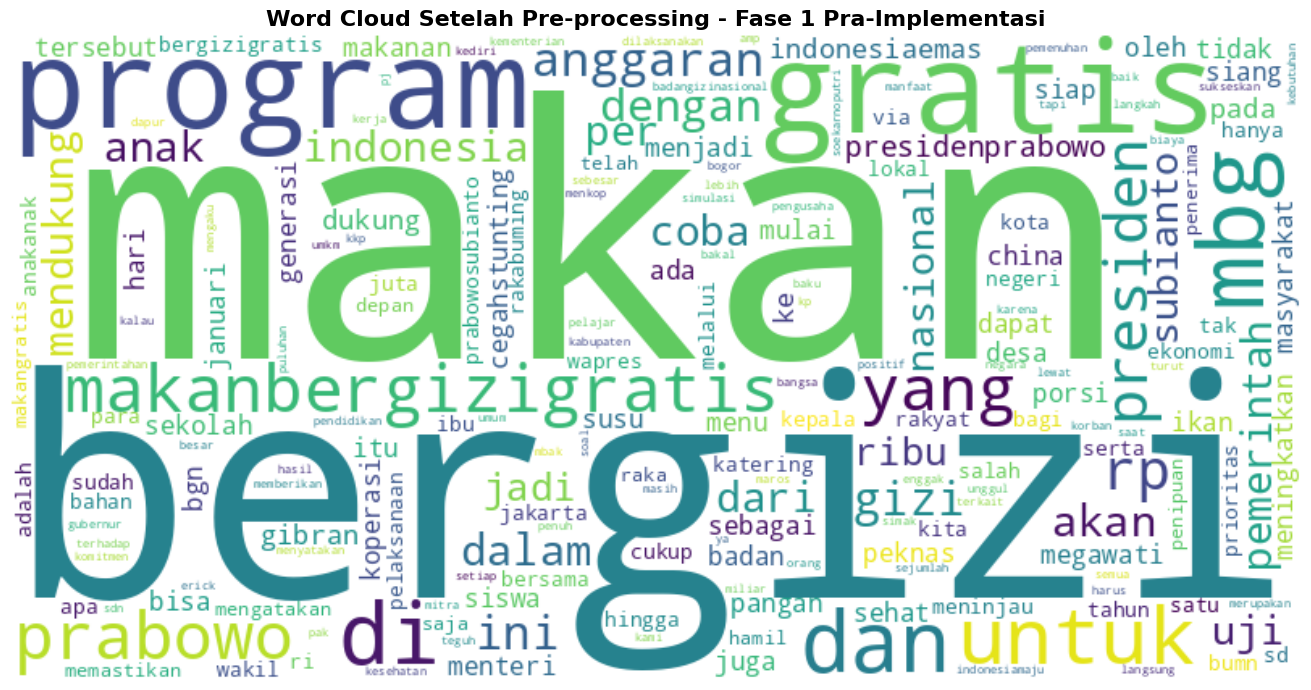

✅ Word Cloud Fase 1 berhasil disimpan!


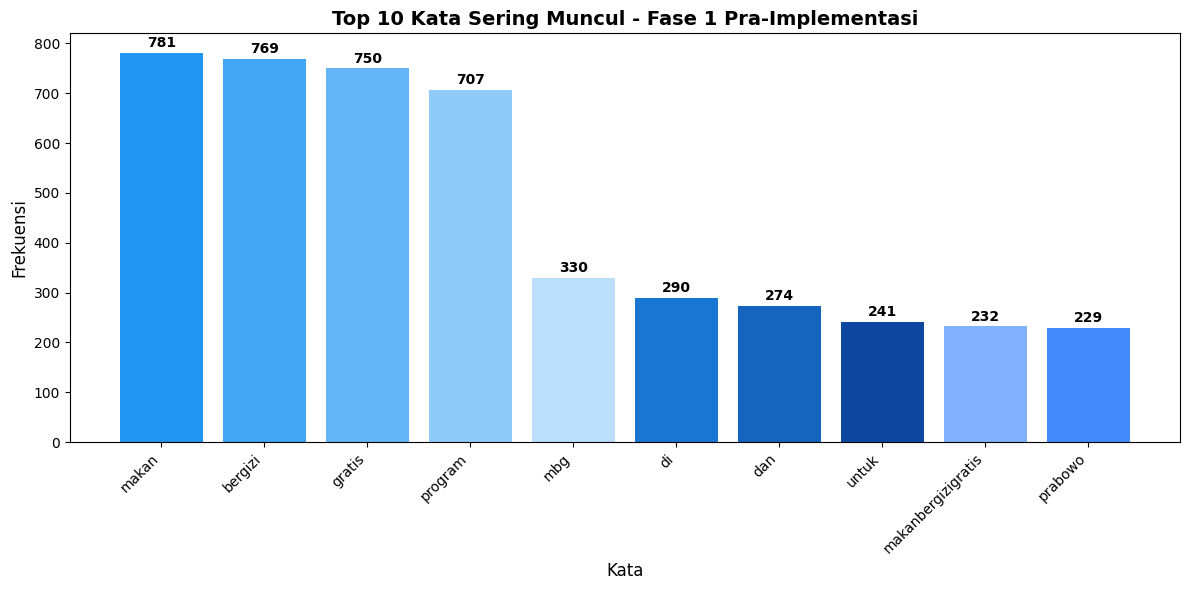

✅ Bar Chart Fase 1 berhasil disimpan!


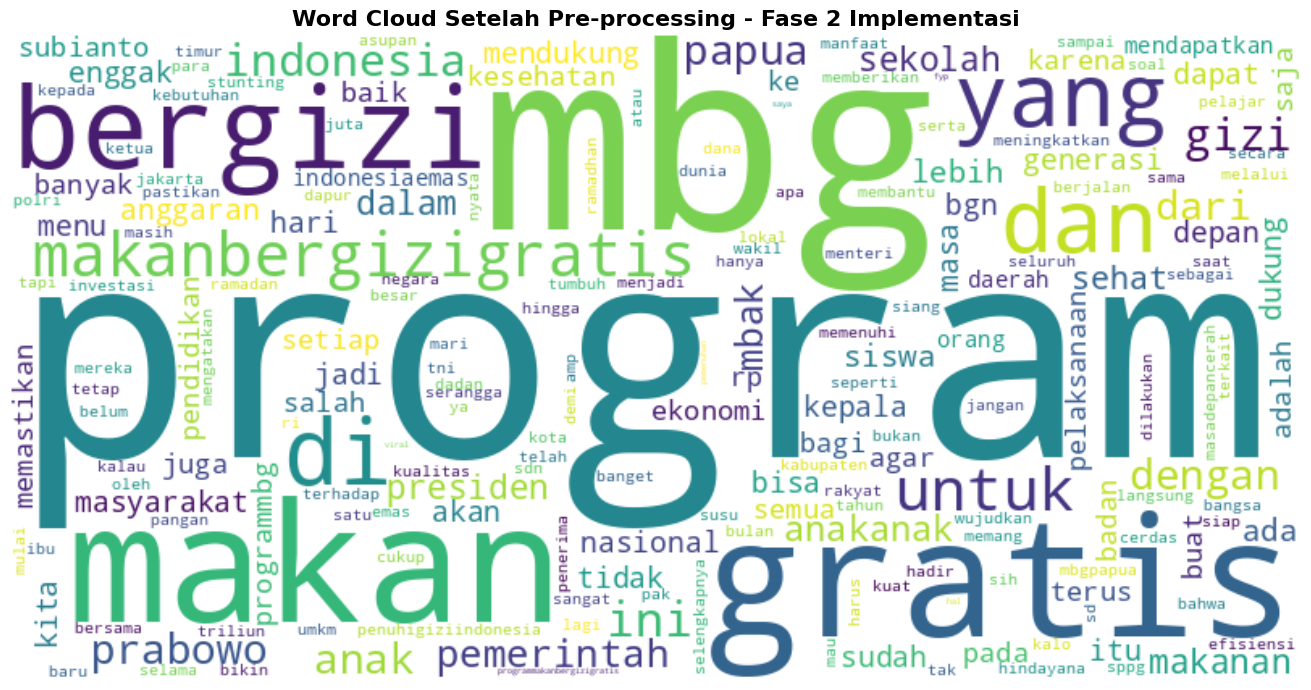

✅ Word Cloud Fase 2 berhasil disimpan!


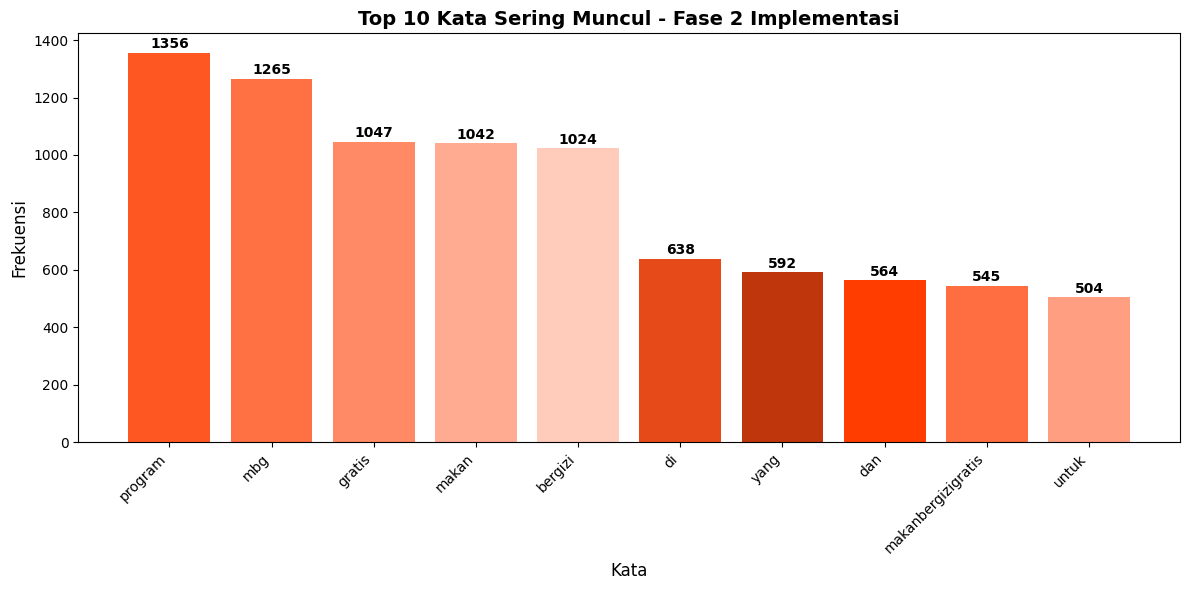

✅ Bar Chart Fase 2 berhasil disimpan!


In [ ]:
# ============================================================
# CELL 9 - WORD CLOUD & TOP 10 KATA SETELAH PRE-PROCESSING
# ============================================================
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import os

save_path_wc = "/content/drive/MyDrive/SKRIPSI/CODE/HASIL_PREPROCESSING"
file_wc1 = f"{save_path_wc}/wordcloud_fase1_clean.png"
file_wc2 = f"{save_path_wc}/wordcloud_fase2_clean.png"
file_bar1 = f"{save_path_wc}/barchart_top10_fase1.png"
file_bar2 = f"{save_path_wc}/barchart_top10_fase2.png"

# Pisah per fase
df['created_at'] = pd.to_datetime(df['created_at'])
df_clean_fase1 = df[df['created_at'] < '2025-01-06']
df_clean_fase2 = df[df['created_at'] >= '2025-01-06']

# ============================================================
# FASE 1 - PRA IMPLEMENTASI
# ============================================================

# Word Cloud Fase 1
if os.path.exists(file_wc1):
    print("⚠️ Word Cloud Fase 1 sudah ada!")
else:
    text1 = " ".join(df_clean_fase1['text_clean'].dropna().values)
    wordcloud1 = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap='viridis',
        max_words=200,
        collocations=False
    ).generate(text1)

    plt.figure(figsize=(14, 7))
    plt.imshow(wordcloud1, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud Setelah Pre-processing - Fase 1 Pra-Implementasi',
              fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(file_wc1, dpi=300)
    plt.show()
    print("✅ Word Cloud Fase 1 berhasil disimpan!")

# Bar Chart Top 10 Fase 1
if os.path.exists(file_bar1):
    print("⚠️ Bar Chart Fase 1 sudah ada!")
else:
    words1 = " ".join(df_clean_fase1['text_clean'].dropna().values).split()
    top10_fase1 = Counter(words1).most_common(10)
    kata1, frek1 = zip(*top10_fase1)

    plt.figure(figsize=(12, 6))
    bars = plt.bar(kata1, frek1, color=['#2196F3', '#42A5F5', '#64B5F6', '#90CAF9', '#BBDEFB',
                                         '#1976D2', '#1565C0', '#0D47A1', '#82B1FF', '#448AFF'])

    for bar, val in zip(bars, frek1):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.xlabel('Kata', fontsize=12)
    plt.ylabel('Frekuensi', fontsize=12)
    plt.title('Top 10 Kata Sering Muncul - Fase 1 Pra-Implementasi',
              fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(file_bar1, dpi=300)
    plt.show()
    print("✅ Bar Chart Fase 1 berhasil disimpan!")

# ============================================================
# FASE 2 - IMPLEMENTASI
# ============================================================

# Word Cloud Fase 2
if os.path.exists(file_wc2):
    print("\n⚠️ Word Cloud Fase 2 sudah ada!")
else:
    text2 = " ".join(df_clean_fase2['text_clean'].dropna().values)
    wordcloud2 = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap='viridis',
        max_words=200,
        collocations=False
    ).generate(text2)

    plt.figure(figsize=(14, 7))
    plt.imshow(wordcloud2, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud Setelah Pre-processing - Fase 2 Implementasi',
              fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(file_wc2, dpi=300)
    plt.show()
    print("✅ Word Cloud Fase 2 berhasil disimpan!")

# Bar Chart Top 10 Fase 2
if os.path.exists(file_bar2):
    print("⚠️ Bar Chart Fase 2 sudah ada!")
else:
    words2 = " ".join(df_clean_fase2['text_clean'].dropna().values).split()
    top10_fase2 = Counter(words2).most_common(10)
    kata2, frek2 = zip(*top10_fase2)

    plt.figure(figsize=(12, 6))
    bars = plt.bar(kata2, frek2, color=['#FF5722', '#FF7043', '#FF8A65', '#FFAB91', '#FFCCBC',
                                         '#E64A19', '#BF360C', '#FF3D00', '#FF6E40', '#FF9E80'])

    for bar, val in zip(bars, frek2):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.xlabel('Kata', fontsize=12)
    plt.ylabel('Frekuensi', fontsize=12)
    plt.title('Top 10 Kata Sering Muncul - Fase 2 Implementasi',
              fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(file_bar2, dpi=300)
    plt.show()
    print("✅ Bar Chart Fase 2 berhasil disimpan!")